# Perf Logs: Query-Level Comparative Analysis

This notebook analyzes perf-stat logs under `./logs/perf_logs` using the new grouped file layout.

It will:
- Recursively load all `*.perfstat.csv` files from `./logs/perf_logs`
- Parse run and query metadata from file names and metadata sidecar files
- Keep analysis at **individual query** granularity (no chunk-level aggregation assumptions)
- Compare queries for each event
- Compare the same query/event across PCs (when multiple PCs are present)

In [73]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

base_dir = Path("./logs/perf_logs")
perf_files = sorted(base_dir.rglob("*.perfstat.csv"))
meta_files = sorted(base_dir.rglob("*__perf_metadata.txt"))

print(f"Found {len(perf_files):,} perfstat files under {base_dir}")
print(f"Found {len(meta_files):,} metadata files under {base_dir}")

# Supported file formats (new + backward-compatible):
# 1) RUNID__QUERY.sql.perfstat.csv
# 2) RUNID__QUERY.sql__CHUNK_REPEAT.perfstat.csv (legacy)
# 3) PCID__RUNID__QUERY.sql.perfstat.csv (optional grouped-by-PC naming)
patterns = [
    re.compile(r"^(?P<run_id>[A-F0-9]+)__(?P<query_file>.+?)\.perfstat\.csv$") ,
    re.compile(r"^(?P<run_id>[A-F0-9]+)__(?P<query_file>.+?)__(?P<chunk>\d+)_(?P<repeat>\d+)\.perfstat\.csv$"),
    re.compile(r"^(?P<pc_id>[A-Za-z0-9_-]+)__(?P<run_id>[A-F0-9]+)__(?P<query_file>.+?)\.perfstat\.csv$"),
]

col_names = [
    "value_raw",
    "unit",
    "event",
    "runtime_count",
    "runtime_pct",
    "ratio",
    "ratio_desc",
]

def parse_key_value_file(path: Path) -> dict:
    out = {}
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        if "=" not in line:
            continue
        k, v = line.split("=", 1)
        out[k.strip()] = v.strip()
    return out

run_meta = {}
for meta_path in meta_files:
    m = re.match(r"^(?P<run_id>[A-F0-9]+)__perf_metadata\.txt$", meta_path.name)
    if not m:
        continue
    rid = m.group("run_id")
    run_meta[rid] = parse_key_value_file(meta_path)

frames = []
parse_failures = []

for fp in perf_files:
    parsed = None
    for pat in patterns:
        m = pat.match(fp.name)
        if m:
            parsed = m.groupdict()
            break

    if parsed is None:
        parse_failures.append(fp.name)
        continue

    rid = parsed.get("run_id", "")
    meta = run_meta.get(rid, {})
    df = pd.read_csv(
        fp,
        comment="#",
        header=None,
        names=col_names,
        on_bad_lines="skip",
    )

    if df.empty:
        continue

    n_events = max(df["event"].nunique(dropna=True), 1)
    df["sample_idx"] = (np.arange(len(df)) // n_events) + 1

    df["run_id"] = rid
    df["pc_id"] = rid
    df["query_file"] = parsed.get("query_file", "")
    df["query_name"] = df["query_file"].str.replace(r"\.sql$", "", regex=True)
    df["chunk"] = pd.to_numeric(parsed.get("chunk"), errors="coerce")
    df["repeat"] = pd.to_numeric(parsed.get("repeat"), errors="coerce")
    df["run_started_utc"] = meta.get("run_started_utc")
    df["query_filter"] = meta.get("query_filter")
    df["source_file"] = str(fp.relative_to(base_dir))

    frames.append(df)

perf_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=col_names)

for c in ["value_raw", "runtime_count", "runtime_pct", "ratio", "chunk", "repeat", "sample_idx"]:
    if c in perf_df.columns:
        perf_df[c] = pd.to_numeric(perf_df[c], errors="coerce")

print(f"Loaded rows: {len(perf_df):,}")
print(f"Filename parse failures: {len(parse_failures)}")
if parse_failures:
    print("Examples:", parse_failures[:5])

perf_df.head(10)

Found 44 perfstat files under logs\perf_logs
Found 2 metadata files under logs\perf_logs
Loaded rows: 39,600
Filename parse failures: 0


,value_raw,unit,event,runtime_count,runtime_pct,ratio,ratio_desc,sample_idx,run_id,pc_id,query_file,query_name,chunk,repeat,run_started_utc,query_filter,source_file
0,139263281,NaN,cycles,34924534,66.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
1,138761495,NaN,instructions,43988100,83.0,1.00,insn per cycle,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
2,28318290,NaN,branches,44327208,83.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
3,983598,NaN,branch-misses,42954989,81.0,3.47,of all branches,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
4,6159110,NaN,cache-references,44522829,84.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
5,1090073,NaN,cache-misses,44855704,84.0,17.70,of all cache refs,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
6,16,NaN,context-switches,52896316,100.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
7,3,NaN,cpu-migrations,52896316,100.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
8,2448,NaN,page-faults,52896316,100.0,NaN,NaN,1,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...
9,141144801,NaN,cycles,35590306,66.0,NaN,NaN,2,3C723810B7265DF2,3C723810B7265DF2,APX1090-queryA.sql,APX1090-queryA,NaN,NaN,2026-04-05T21:38:20Z,all,perf_runs\3C723810B7265DF2__APX1090-queryA.sql...


In [74]:
# Dataset quality + individual-query coverage
summary = {
    "rows": len(perf_df),
    "columns": perf_df.shape[1],
    "n_pcs": perf_df["pc_id"].nunique(dropna=True),
    "n_run_ids": perf_df["run_id"].nunique(dropna=True),
    "n_queries": perf_df["query_name"].nunique(dropna=True),
    "n_events": perf_df["event"].nunique(dropna=True),
    "n_source_files": perf_df["source_file"].nunique(dropna=True),
}

print("Dataset summary:")
display(pd.Series(summary, name="value").to_frame())

print("\nCoverage by PC and query (number of sample runs):")
coverage = (
    perf_df.groupby(["pc_id", "query_name"], dropna=False)["sample_idx"]
    .nunique()
    .rename("n_samples")
    .reset_index()
    .sort_values(["pc_id", "query_name"])
)
display(coverage)

print("\nTop events by row count:")
display(perf_df["event"].value_counts().rename_axis("event").to_frame("rows"))

print("\nMissingness (%):")
display((perf_df.isna().mean() * 100).round(2).sort_values(ascending=False).rename("pct_missing").to_frame())

Dataset summary:


,value
rows,39600
columns,17
n_pcs,2
n_run_ids,2
n_queries,22
n_events,9
n_source_files,44



Coverage by PC and query (number of sample runs):


,pc_id,query_name,n_samples
0,3C723810B7265DF2,APX1090-queryA,100
1,3C723810B7265DF2,APX1090-queryB,100
2,3C723810B7265DF2,APX1092-queryA,100
3,3C723810B7265DF2,APX1092-queryB,100
4,3C723810B7265DF2,APX1130-queryA,100
5,3C723810B7265DF2,APX1130-queryB,100
6,3C723810B7265DF2,APX1145-queryA,100
7,3C723810B7265DF2,APX1145-queryB,100
8,3C723810B7265DF2,APX1173-queryA,100
9,3C723810B7265DF2,APX1173-queryB,100



Top events by row count:


,rows
event,
cycles,4400
instructions,4400
branches,4400
branch-misses,4400
cache-references,4400
cache-misses,4400
context-switches,4400
cpu-migrations,4400
page-faults,4400



Missingness (%):


,pct_missing
unit,100.00
repeat,100.00
chunk,100.00
ratio_desc,66.67
ratio,66.67
value_raw,0.00
runtime_count,0.00
runtime_pct,0.00
event,0.00
run_id,0.00


In [75]:
# Query-level comparison (always per individual query)
core_events = [
    "cycles",
    "instructions",
    "branches",
    "branch-misses",
    "cache-references",
    "cache-misses",
    "context-switches",
    "cpu-migrations",
    "page-faults",
]

query_event_stats = (
    perf_df.groupby(["pc_id", "query_name", "event"], dropna=False)["value_raw"]
    .agg(count="count", mean_value="mean", median_value="median", std_value="std", p95_value=lambda s: s.quantile(0.95))
    .reset_index()
)

print("Per-query stats (long format):")
display(
    query_event_stats.sort_values(["pc_id", "query_name", "event"]).reset_index(drop=True)
 )

print("\nQuery comparison table (median value by event within each PC):")
query_compare = (
    query_event_stats[query_event_stats["event"].isin(core_events)]
    .pivot_table(index="query_name", columns=["pc_id", "event"], values="median_value")
    .sort_index()
)
display(query_compare)

print("\nQuery ranking by median cycles (lower is better):")
cycles_rank = (
    query_event_stats[query_event_stats["event"] == "cycles"]
    .sort_values(["pc_id", "median_value", "query_name"])[["pc_id", "query_name", "median_value", "std_value", "count"]]
    .rename(columns={"median_value": "cycles_median", "std_value": "cycles_std"})
)
display(cycles_rank)

Per-query stats (long format):


,pc_id,query_name,event,count,mean_value,median_value,std_value,p95_value
0,3C723810B7265DF2,APX1090-queryA,branch-misses,100,9.700481e+05,970289.0,1.095350e+04,9.876321e+05
1,3C723810B7265DF2,APX1090-queryA,branches,100,2.860512e+07,28613287.0,4.969490e+05,2.942798e+07
2,3C723810B7265DF2,APX1090-queryA,cache-misses,100,1.073161e+06,1066545.0,3.159831e+04,1.126203e+06
3,3C723810B7265DF2,APX1090-queryA,cache-references,100,6.154898e+06,6158430.0,8.192946e+04,6.273588e+06
4,3C723810B7265DF2,APX1090-queryA,context-switches,100,1.474000e+01,15.0,9.279063e-01,1.600000e+01
...,...,...,...,...,...,...,...,...
391,3FCB6067AE1B0BCE,PE019-queryB,context-switches,100,1.252000e+01,12.0,1.760854e+00,1.400000e+01
392,3FCB6067AE1B0BCE,PE019-queryB,cpu-migrations,100,2.200000e-01,0.0,5.959459e-01,2.000000e+00
393,3FCB6067AE1B0BCE,PE019-queryB,cycles,100,1.338099e+08,133477156.0,2.489655e+06,1.353669e+08
394,3FCB6067AE1B0BCE,PE019-queryB,instructions,100,1.421183e+08,142227906.5,1.329100e+06,1.439391e+08



Query comparison table (median value by event within each PC):


pc_id          3C723810B7265DF2                                                                                                                 3FCB6067AE1B0BCE                                            \
event             branch-misses    branches cache-misses cache-references context-switches cpu-migrations       cycles instructions page-faults    branch-misses    branches cache-misses cache-references   
query_name                                                                                                                                                                                                   
APX1090-queryA         970289.0  28613287.0    1066545.0        6158430.0             15.0            3.0  138721024.5  140700637.5      2446.0         975194.0  28194084.5     671756.5        6023907.5   
APX1090-queryB         971395.5  28648491.0    1065160.0        6195156.0             15.0            4.0  138936934.0  140606417.5      2447.0         978476.5  28212182.0     682244.0        6018965.5   
APX1092-queryA         972449.5  29084537.0    1069719.5        6212786.0             14.0            3.0  138844000.5  141671939.0      2447.0         991095.5  28453643.0     672601.0        6047872.0   
APX1092-queryB         971990.5  29039407.5    1078999.5        6201766.5             14.0            4.0  138967497.5  142390436.5      2447.0         991595.5  28478947.5     672655.0        6069277.0   
APX1130-queryA         973125.0  28728396.5    1065258.0        6194554.5             15.0            3.0  139555192.0  140875546.0      2447.0         976949.5  28195976.0     678384.5        6029304.0   
APX1130-queryB         975429.0  28621592.5    1064480.5        6173849.0             14.0            4.0  139025591.5  140553194.5      2446.0         977233.0  28203110.0     677653.5        6023823.0   
APX1145-queryA         973896.0  28774026.5    1055554.0        6209175.0             14.0            3.0  139603942.5  141427224.5      2447.0         983082.0  28236818.0     679252.5        6007128.0   
APX1145-queryB         969928.5  28756501.5    1062599.0        6198648.0             14.5            3.0  139069288.0  141350709.0      2446.0         980559.0  28234560.0     680283.0        6020147.5   
APX1173-queryA         975895.0  28783387.5    1069619.0        6201319.5             15.0            3.0  139482555.5  141288877.5      2446.0         978236.0  28243610.5     678804.0        6034490.0   
APX1173-queryB         973228.5  28913490.0    1075151.5        6193881.0             14.0            4.0  139140781.0  141536886.5      2447.0         980735.5  28318819.0     678931.0        6045664.5   
APX1186-queryA         971065.5  28808921.0    1069244.0        6236417.5             15.0            3.0  139548797.0  141152939.5      2446.0         976652.0  28186575.5     679529.5        6013180.0   
APX1186-queryB        1024704.5  38303424.0    1136569.0        6385983.0             29.0            5.0  155137033.0  174519143.0      2538.0        1036911.0  36891266.0     717915.5        6205776.5   
APX1225-queryA         975228.0  28839833.0    1069470.0        6216565.5             14.0            3.0  139195089.5  141803387.0      2447.0         983679.5  28368382.5     666265.0        6030289.5   
APX1225-queryB         971580.5  28896672.0    1072138.0        6193695.5             14.0            3.0  139080463.0  141676093.0      2447.0         977467.5  28239251.5     662121.5        6035236.0   
APX1278-queryA         971563.0  28734693.0    1068466.5        6201550.5             14.0            3.0  139638462.5  141287379.5      2446.0         977343.5  28323688.5     670910.0        6011760.5   
APX1278-queryB         970603.0  28733300.5    1054028.0        6189273.5             14.0            3.5  138921086.0  141185567.0      2446.0         983410.0  28305478.0     661539.0        6060674.0   
PE002-queryA           970252.5  28857103.5    1070219.0        6201164.0             


Query ranking by median cycles (lower is better):


,pc_id,query_name,cycles_median,cycles_std,count
6,3C723810B7265DF2,APX1090-queryA,138721024.5,9.579935e+05,100
24,3C723810B7265DF2,APX1092-queryA,138844000.5,9.062139e+05,100
150,3C723810B7265DF2,PE002-queryA,138856285.5,1.108544e+06,100
141,3C723810B7265DF2,APX1278-queryB,138921086.0,9.459698e+05,100
15,3C723810B7265DF2,APX1090-queryB,138936934.0,9.910400e+05,100
33,3C723810B7265DF2,APX1092-queryB,138967497.5,1.145322e+06,100
51,3C723810B7265DF2,APX1130-queryB,139025591.5,9.807798e+05,100
69,3C723810B7265DF2,APX1145-queryB,139069288.0,8.773338e+05,100
123,3C723810B7265DF2,APX1225-queryB,139080463.0,1.165782e+06,100
195,3C723810B7265DF2,PE019-queryB,139139935.5,9.078413e+05,100


In [76]:
# Cross-PC comparison for the same query/event
pc_count = perf_df["pc_id"].nunique(dropna=True)

if pc_count < 2:
    print("Only one PC found in current dataset; cross-PC comparison needs >= 2 PCs.")
else:
    cross_pc = (
        perf_df.groupby(["query_name", "event", "pc_id"], dropna=False)["value_raw"]
        .median()
        .rename("median_value")
        .reset_index()
    )

    cross_pc_pivot = cross_pc.pivot_table(
        index=["query_name", "event"],
        columns="pc_id",
        values="median_value"
    )

    pc_cols = list(cross_pc_pivot.columns)
    cross_pc_pivot["pc_max"] = cross_pc_pivot[pc_cols].max(axis=1)
    cross_pc_pivot["pc_min"] = cross_pc_pivot[pc_cols].min(axis=1)
    cross_pc_pivot["pc_max_over_min"] = np.where(
        cross_pc_pivot["pc_min"] > 0,
        cross_pc_pivot["pc_max"] / cross_pc_pivot["pc_min"],
        np.nan,
    )

    print("Largest cross-PC spread by query/event (median max/min):")
    display(cross_pc_pivot.sort_values("pc_max_over_min", ascending=False).head(40))

    print("\nCross-PC spread for core events only:")
    core_spread = cross_pc_pivot.reset_index()
    core_spread = core_spread[core_spread["event"].isin([
        "cycles", "instructions", "cache-misses", "branch-misses", "page-faults"
    ])]
    display(core_spread.sort_values(["event", "pc_max_over_min"], ascending=[True, False]))

Largest cross-PC spread by query/event (median max/min):


,pc_id,3C723810B7265DF2,3FCB6067AE1B0BCE,pc_max,pc_min,pc_max_over_min
query_name,event,,,,,
APX1186-queryB,cpu-migrations,5.0,3.0,5.0,3.0,1.666667
PE002-queryB,cache-misses,1074396.5,659327.5,1074396.5,659327.5,1.629534
APX1225-queryB,cache-misses,1072138.0,662121.5,1072138.0,662121.5,1.619247
PE002-queryA,cache-misses,1070219.0,661025.0,1070219.0,661025.0,1.619030
PE019-queryB,cache-misses,1070041.0,666488.5,1070041.0,666488.5,1.605491
APX1225-queryA,cache-misses,1069470.0,666265.0,1069470.0,666265.0,1.605172
APX1092-queryB,cache-misses,1078999.5,672655.0,1078999.5,672655.0,1.604091
APX1278-queryB,cache-misses,1054028.0,661539.0,1054028.0,661539.0,1.593297
APX1278-queryA,cache-misses,1068466.5,670910.0,1068466.5,670910.0,1.592563



Cross-PC spread for core events only:


pc_id,query_name,event,3C723810B7265DF2,3FCB6067AE1B0BCE,pc_max,pc_min,pc_max_over_min
27,APX1092-queryB,branch-misses,971990.5,991595.5,991595.5,971990.5,1.020170
18,APX1092-queryA,branch-misses,972449.5,991095.5,991095.5,972449.5,1.019174
153,PE002-queryB,branch-misses,970263.5,986237.0,986237.0,970263.5,1.016463
135,APX1278-queryB,branch-misses,970603.0,983410.0,983410.0,970603.0,1.013195
99,APX1186-queryB,branch-misses,1024704.5,1036911.0,1036911.0,1024704.5,1.011912
...,...,...,...,...,...,...,...
125,APX1225-queryB,page-faults,2447.0,2448.0,2448.0,2447.0,1.000409
161,PE002-queryB,page-faults,2447.0,2448.0,2448.0,2447.0,1.000409
62,APX1145-queryA,page-faults,2447.0,2447.0,2447.0,2447.0,1.000000
89,APX1173-queryB,page-faults,2447.0,2447.0,2447.0,2447.0,1.000000


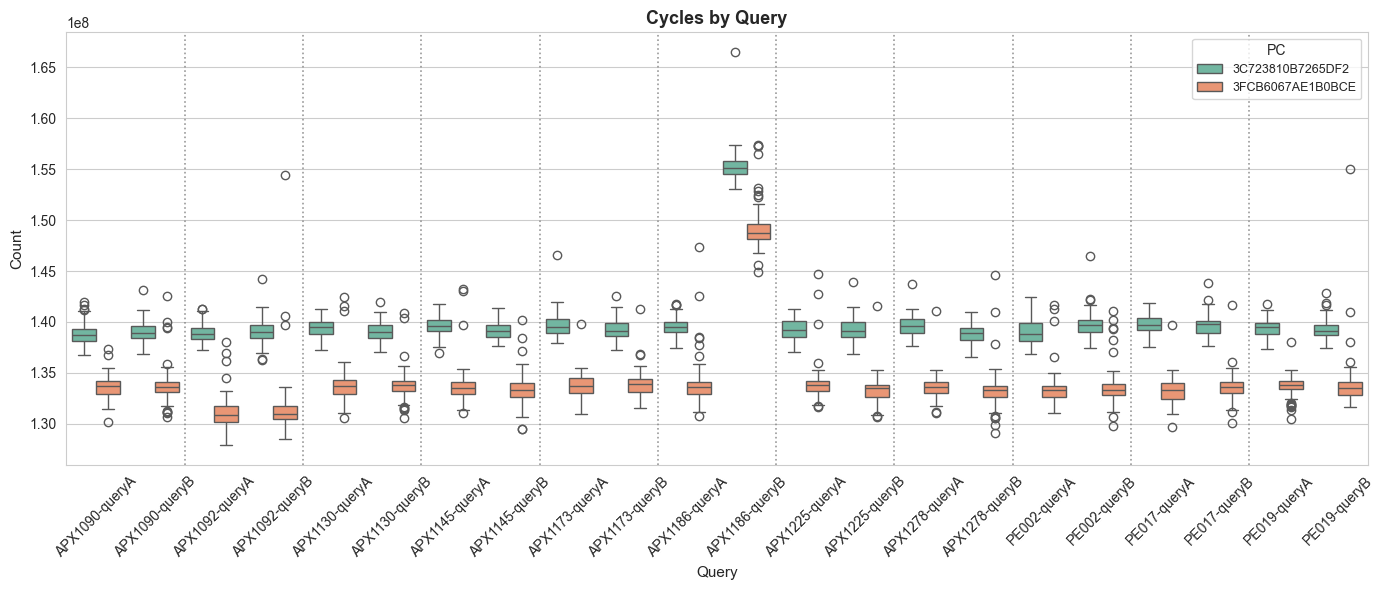

✓ Boxplot (cycles) created


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
sns.set_palette("Set2")

# Prepare data for plotting
plot_events = ["cycles", "instructions", "cache-misses", "branch-misses", "page-faults"]
plot_df = perf_df[perf_df["event"].isin(plot_events)].dropna(subset=["value_raw", "query_name", "event"])
query_order = sorted(plot_df["query_name"].dropna().unique())

def _query_family(name: str) -> str:
    return re.sub(r"-query[AB]$", "", str(name))

def add_ab_group_separators(ax, labels):
    labels = list(labels)
    for i in range(len(labels) - 1):
        if _query_family(labels[i]) != _query_family(labels[i + 1]):
            ax.axvline(i + 0.5, color="gray", linestyle=":", linewidth=1.2, alpha=0.8)

# Boxplot: Cycles
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "cycles"]

if not event_data.empty:
    sns.boxplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        hue="pc_id",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Cycles by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)
    ax.legend(title="PC", fontsize=9, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplot (cycles) created")

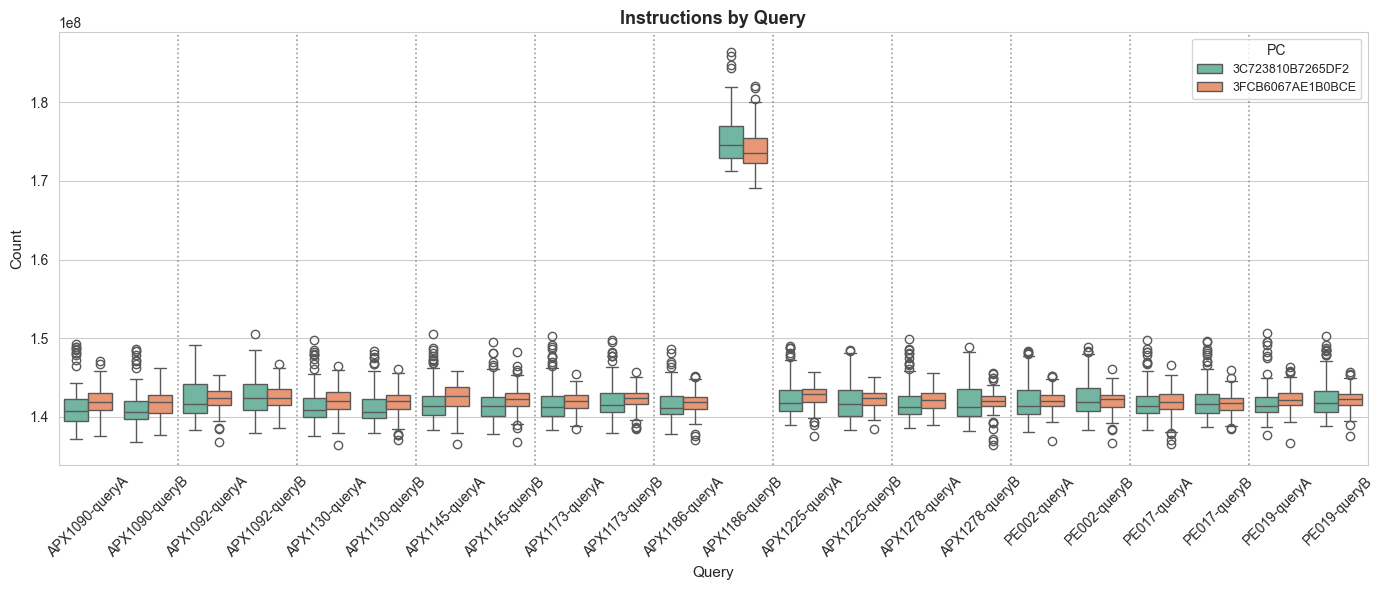

✓ Boxplot (instructions) created


In [78]:
# Boxplot: Instructions
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "instructions"]

if not event_data.empty:
    sns.boxplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        hue="pc_id",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Instructions by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)
    ax.legend(title="PC", fontsize=9, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplot (instructions) created")

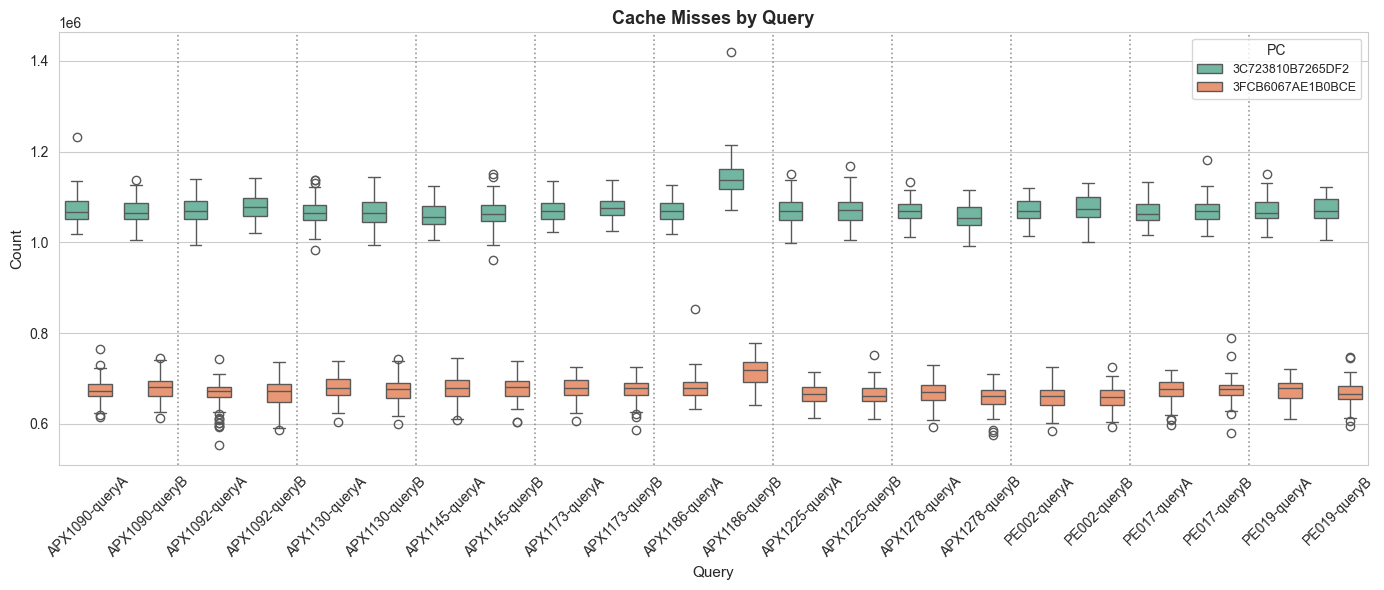

✓ Boxplot (cache-misses) created


In [79]:
# Boxplot: Cache Misses
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "cache-misses"]

if not event_data.empty:
    sns.boxplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        hue="pc_id",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Cache Misses by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)
    ax.legend(title="PC", fontsize=9, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplot (cache-misses) created")

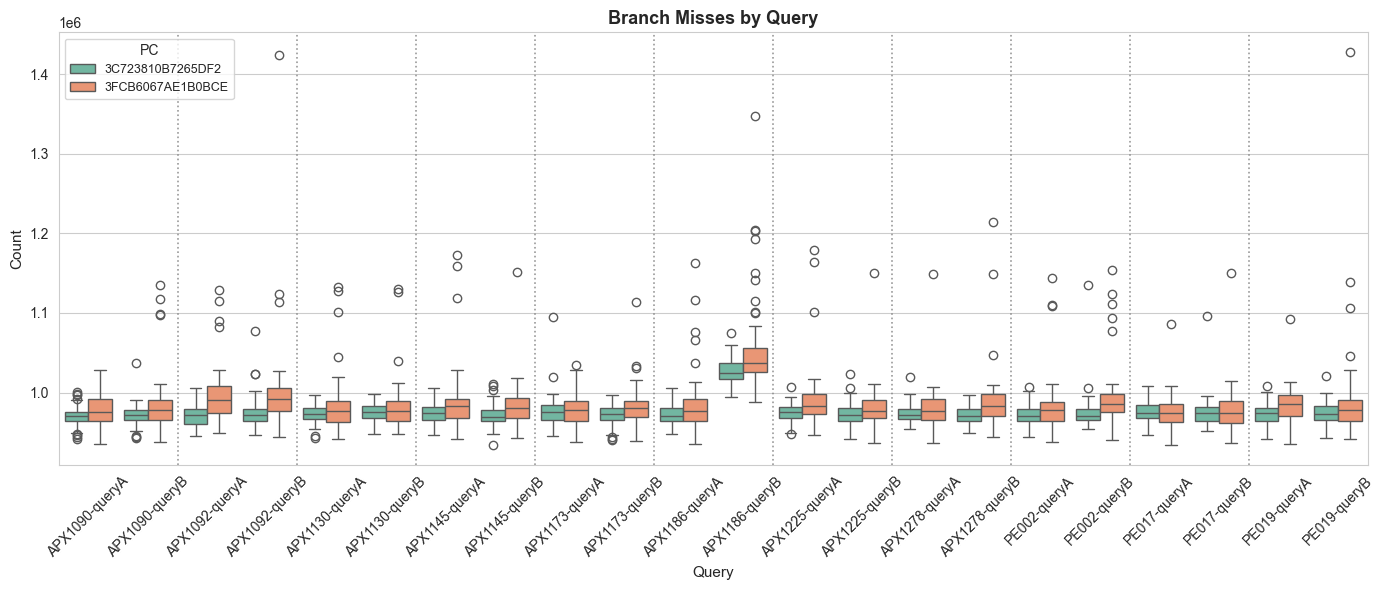

✓ Boxplot (branch-misses) created


In [80]:
# Boxplot: Branch Misses
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "branch-misses"]

if not event_data.empty:
    sns.boxplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        hue="pc_id",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Branch Misses by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)
    ax.legend(title="PC", fontsize=9, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplot (branch-misses) created")

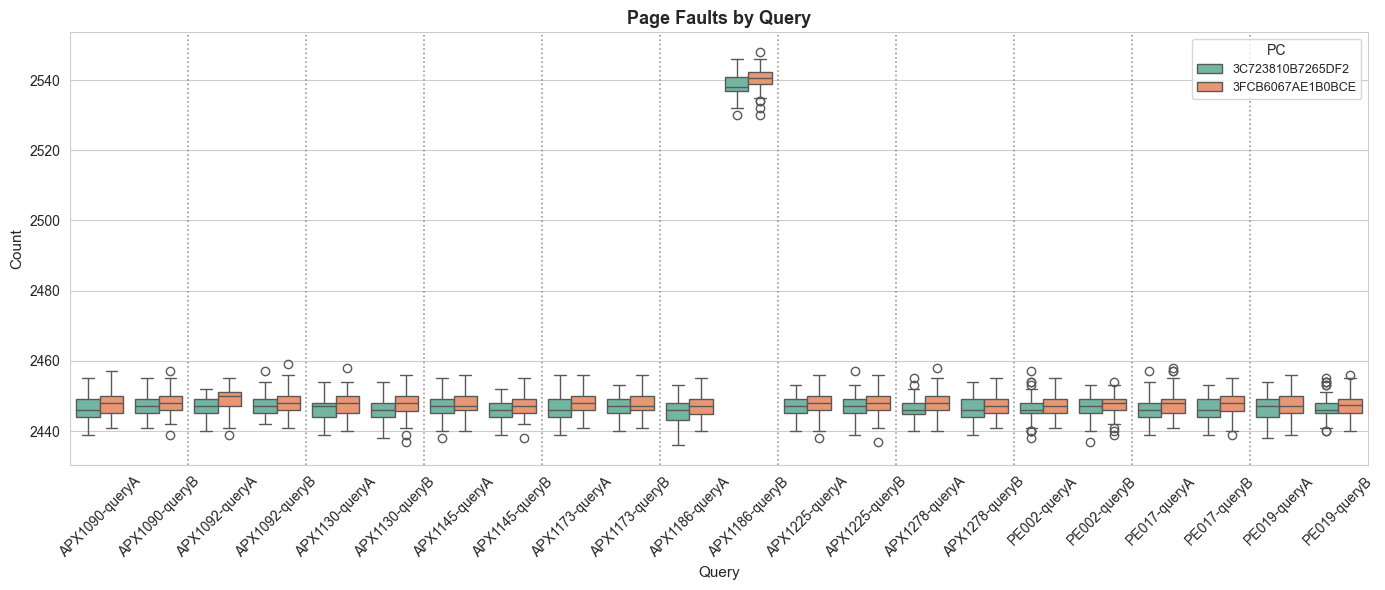

✓ Boxplot (page-faults) created


In [81]:
# Boxplot: Page Faults
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "page-faults"]

if not event_data.empty:
    sns.boxplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        hue="pc_id",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Page Faults by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)
    ax.legend(title="PC", fontsize=9, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplot (page-faults) created")

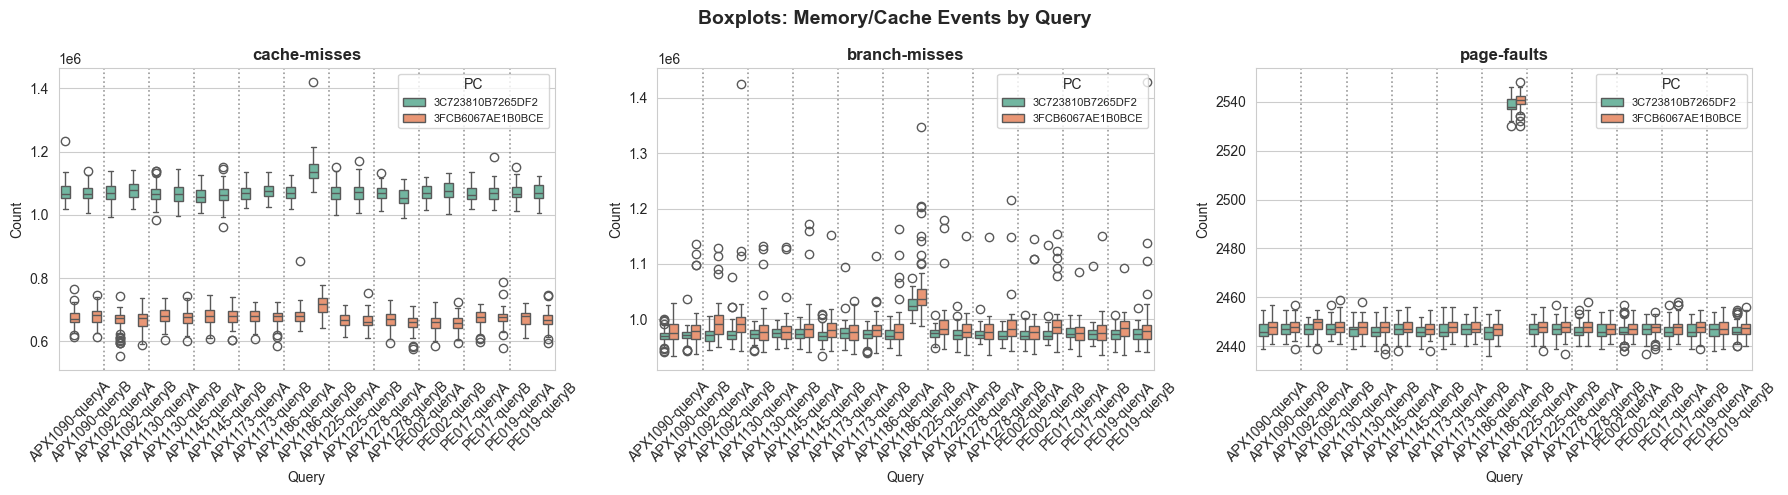

✓ Boxplots (memory/cache events) created


In [82]:
# Boxplots: Memory/Cache Events
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Boxplots: Memory/Cache Events by Query", fontsize=14, fontweight="bold")

memory_events = ["cache-misses", "branch-misses", "page-faults"]
for idx, event in enumerate(memory_events):
    ax = axes[idx]
    event_data = plot_df[plot_df["event"] == event]

    if not event_data.empty:
        sns.boxplot(
            data=event_data,
            x="query_name",
            y="value_raw",
            hue="pc_id",
            order=query_order,
            ax=ax,
            palette="Set2"
        )
        ax.set_title(event, fontsize=12, fontweight="bold")
        ax.set_xlabel("Query", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.tick_params(axis="x", rotation=45)
        add_ab_group_separators(ax, query_order)
        ax.legend(title="PC", fontsize=8, loc="best")

plt.tight_layout()
plt.show()

print("✓ Boxplots (memory/cache events) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2627322684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


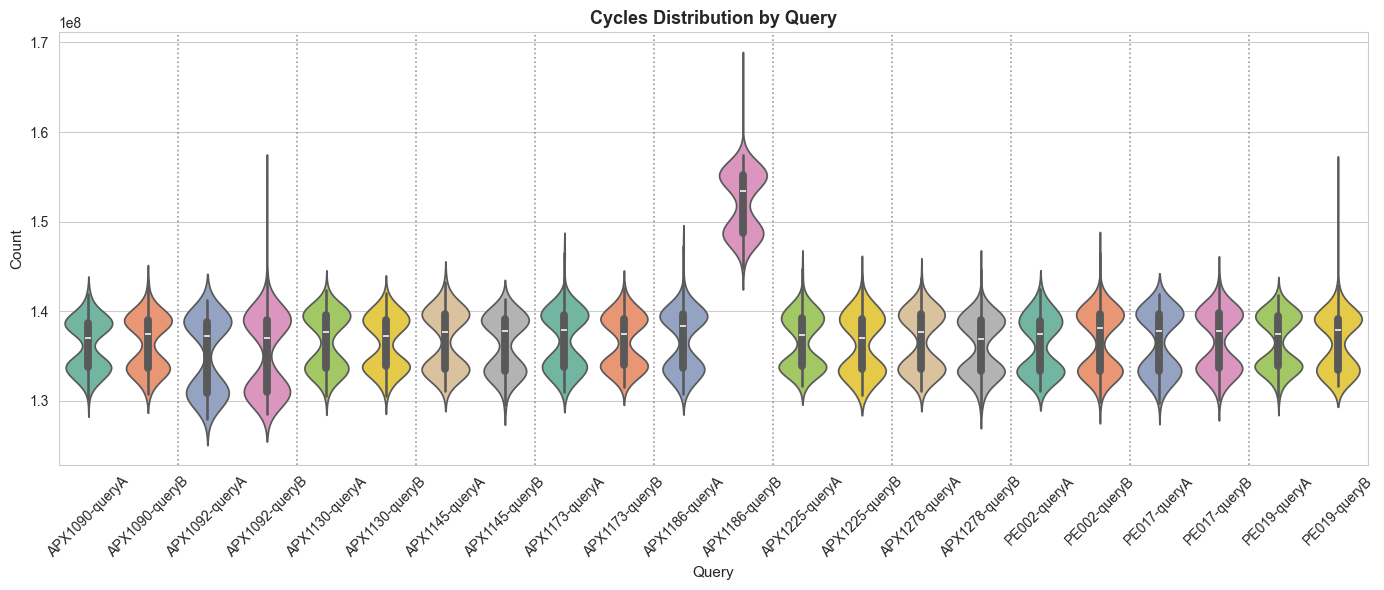

✓ Violin plot (cycles) created


In [83]:
# Violin plot: Cycles
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "cycles"]

if not event_data.empty:
    sns.violinplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Cycles Distribution by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plot (cycles) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2720680828.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


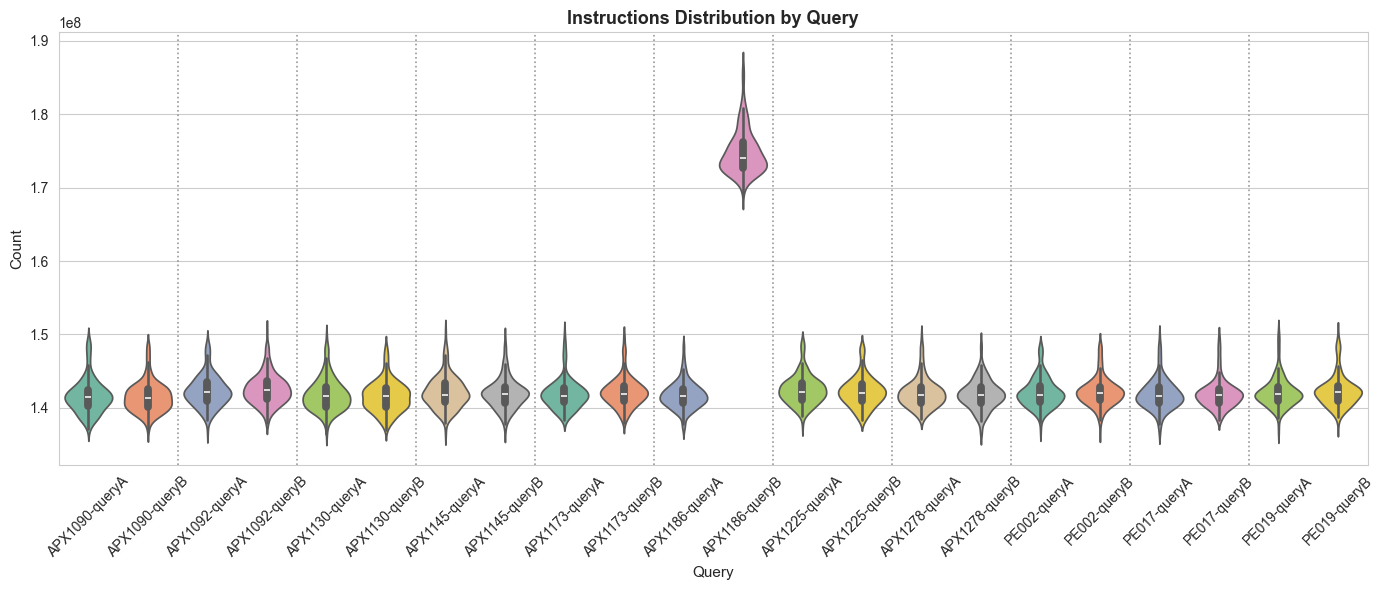

✓ Violin plot (instructions) created


In [84]:
# Violin plot: Instructions
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "instructions"]

if not event_data.empty:
    sns.violinplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Instructions Distribution by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plot (instructions) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1183527347.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


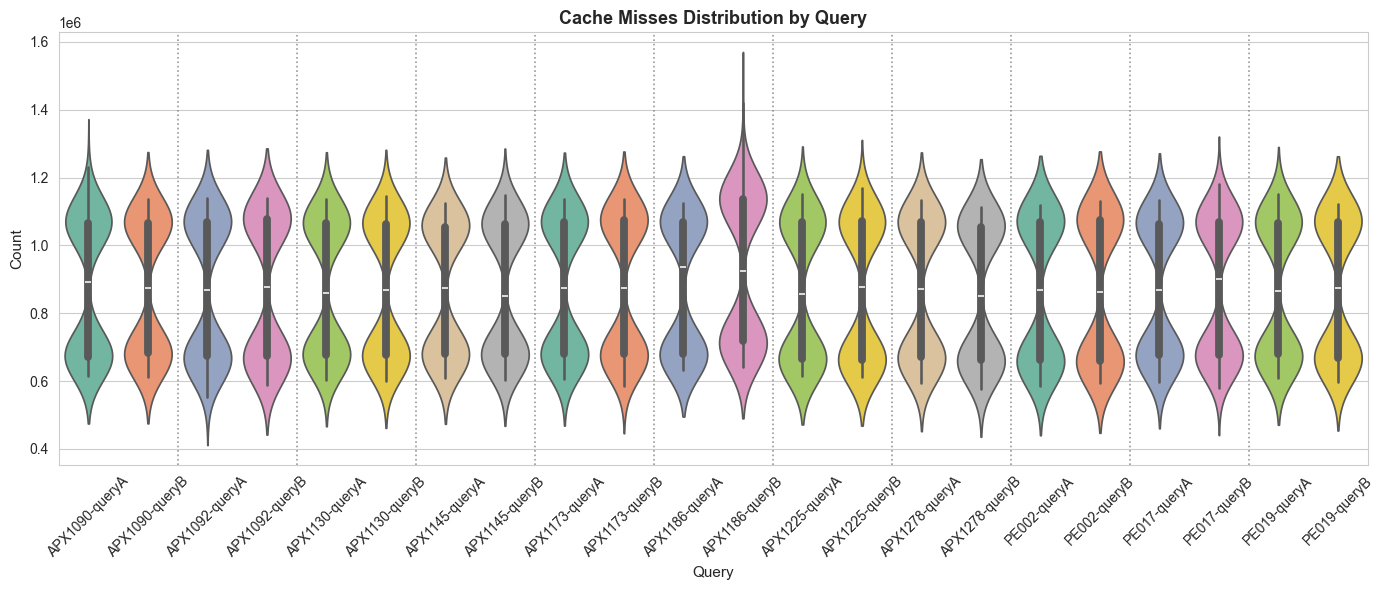

✓ Violin plot (cache-misses) created


In [85]:
# Violin plot: Cache Misses
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "cache-misses"]

if not event_data.empty:
    sns.violinplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Cache Misses Distribution by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plot (cache-misses) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3512719805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


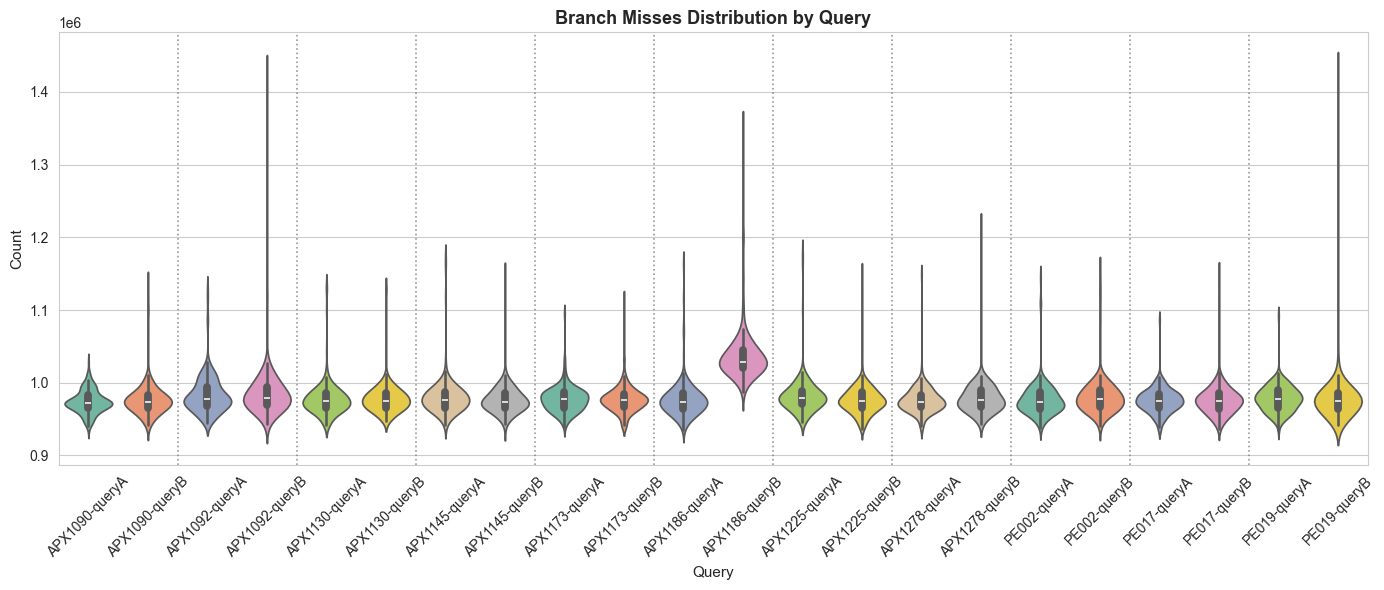

✓ Violin plot (branch-misses) created


In [86]:
# Violin plot: Branch Misses
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "branch-misses"]

if not event_data.empty:
    sns.violinplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Branch Misses Distribution by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plot (branch-misses) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1383538163.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


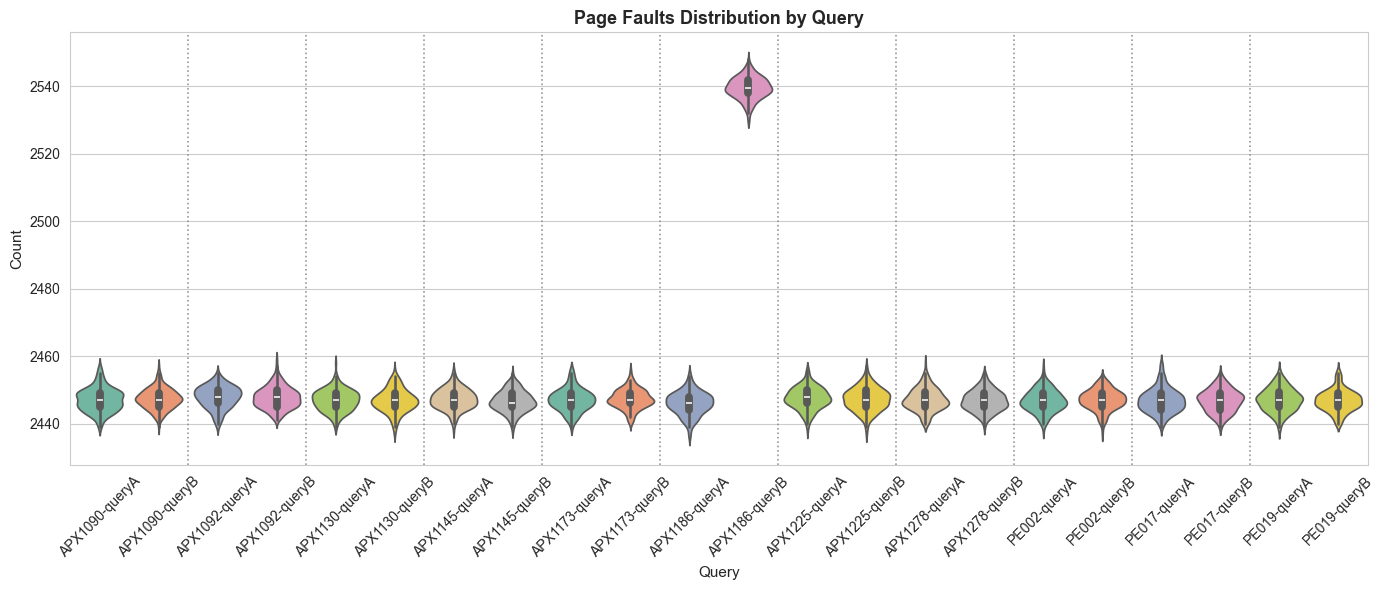

✓ Violin plot (page-faults) created


In [87]:
# Violin plot: Page Faults
fig, ax = plt.subplots(figsize=(14, 6))
event_data = plot_df[plot_df["event"] == "page-faults"]

if not event_data.empty:
    sns.violinplot(
        data=event_data,
        x="query_name",
        y="value_raw",
        order=query_order,
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Page Faults Distribution by Query", fontsize=13, fontweight="bold")
    ax.set_xlabel("Query", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plot (page-faults) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4163182561.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4163182561.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4163182561.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


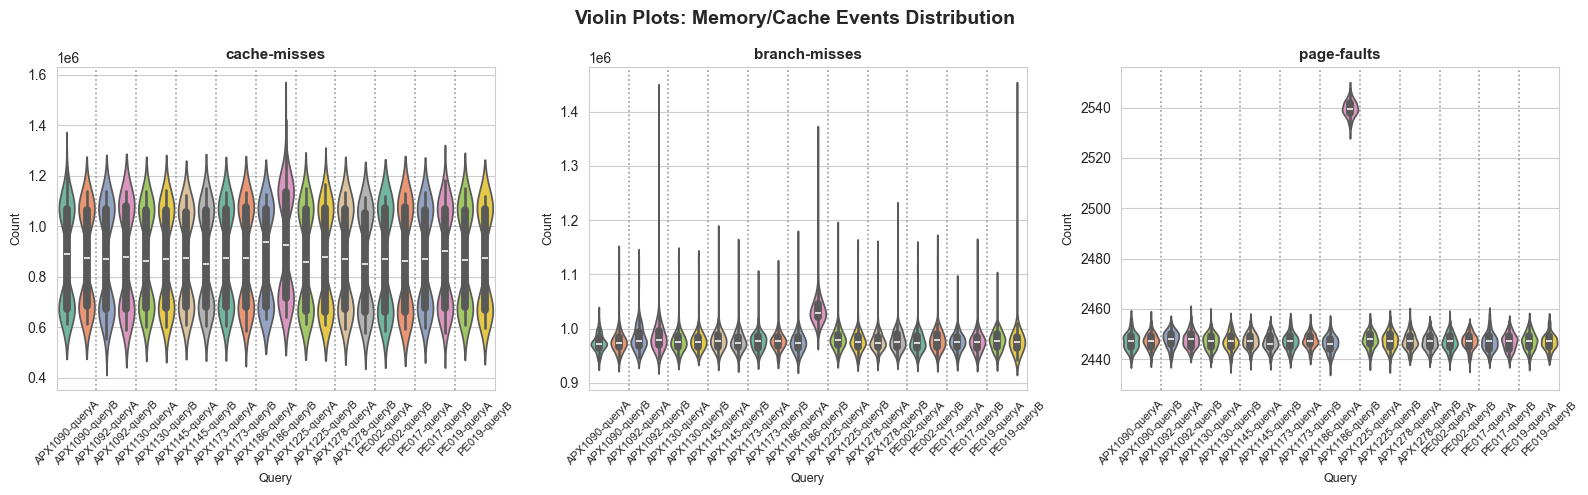

✓ Violin plots (memory/cache events) created


In [88]:
# Violin plots: Memory/Cache Events
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Violin Plots: Memory/Cache Events Distribution", fontsize=14, fontweight="bold")

memory_events = ["cache-misses", "branch-misses", "page-faults"]
for idx, event in enumerate(memory_events):
    ax = axes[idx]
    event_data = plot_df[plot_df["event"] == event]

    if not event_data.empty:
        sns.violinplot(
            data=event_data,
            x="query_name",
            y="value_raw",
            order=query_order,
            ax=ax,
            palette="Set2"
        )
        ax.set_title(event, fontsize=11, fontweight="bold")
        ax.set_xlabel("Query", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        add_ab_group_separators(ax, query_order)

plt.tight_layout()
plt.show()

print("✓ Violin plots (memory/cache events) created")

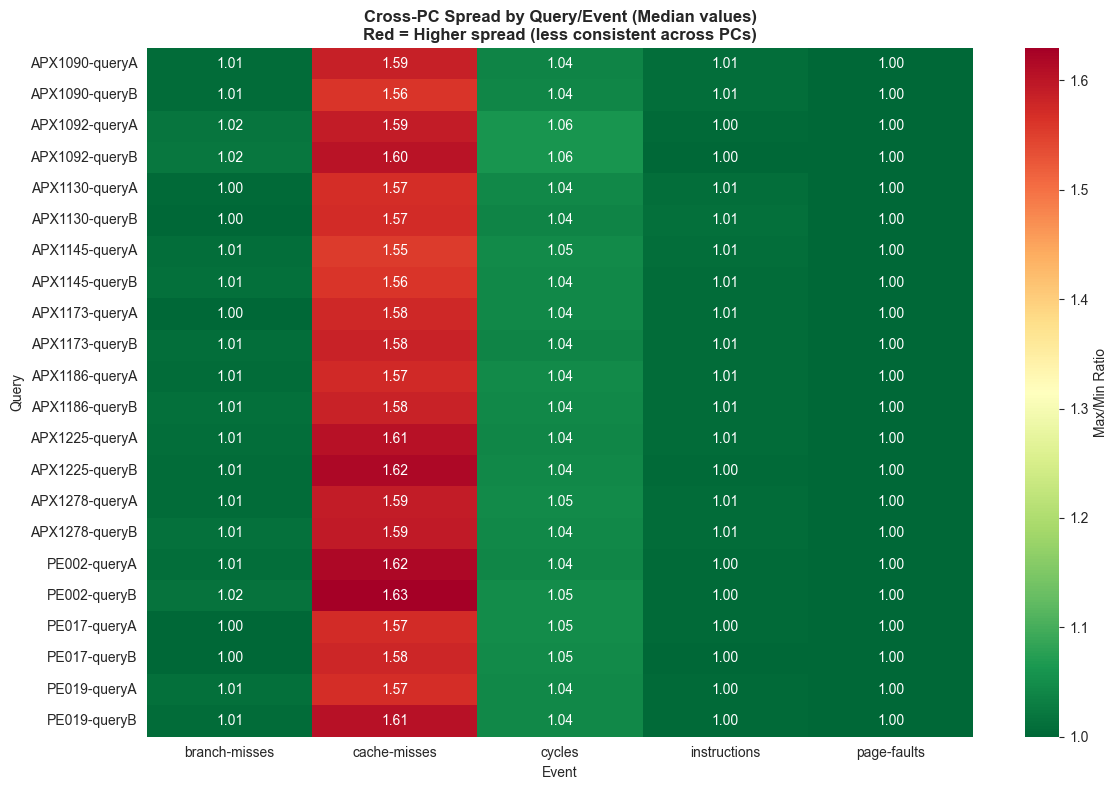

✓ Cross-PC spread heatmap created


In [89]:
# Cross-PC spread heatmap: max/min ratio for each query/event
if pc_count >= 2:
    spread_data = core_spread[["query_name", "event", "pc_max_over_min"]].copy()
    spread_pivot = spread_data.pivot_table(
        index="query_name",
        columns="event",
        values="pc_max_over_min"
    )
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        spread_pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        cbar_kws={"label": "Max/Min Ratio"},
        ax=ax
    )
    ax.set_title("Cross-PC Spread by Query/Event (Median values)\nRed = Higher spread (less consistent across PCs)", 
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Event", fontsize=10)
    ax.set_ylabel("Query", fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Cross-PC spread heatmap created")
else:
    print("Skipped cross-PC spread heatmap (need >= 2 PCs)")

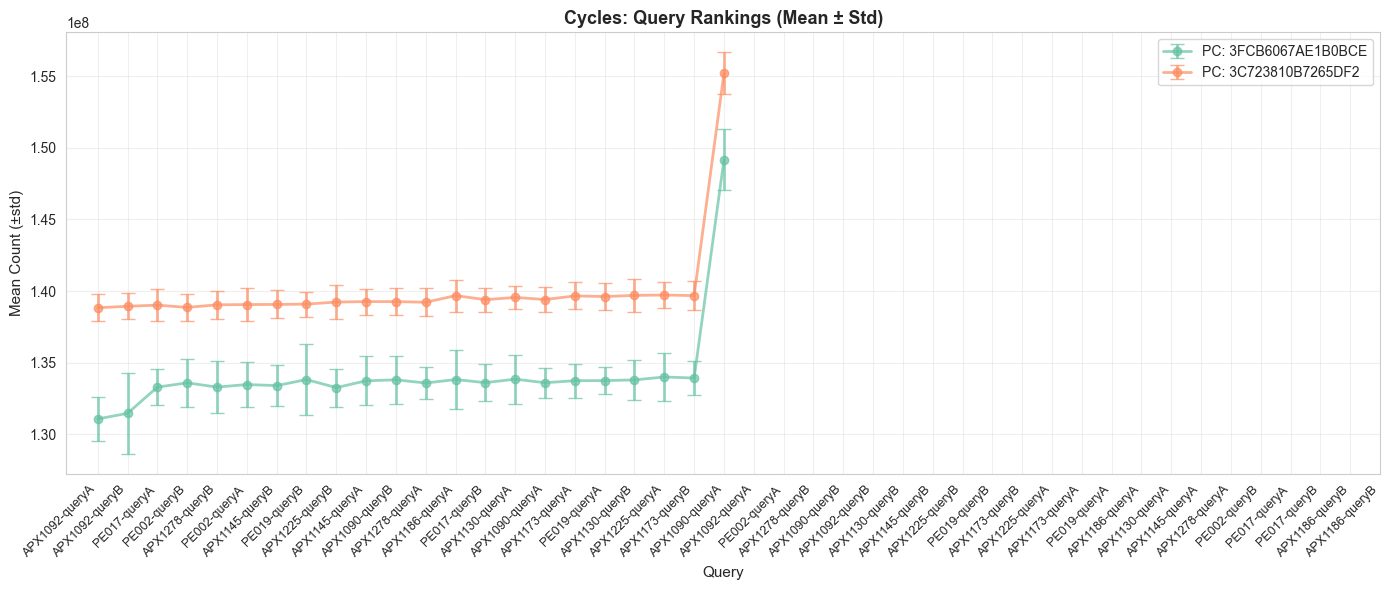

✓ Query ranking (cycles) created


In [90]:
# Query ranking: Cycles
fig, ax = plt.subplots(figsize=(14, 6))

event_stats = query_event_stats[query_event_stats["event"] == "cycles"].copy()
event_stats = event_stats.sort_values("median_value", ascending=True)

if not event_stats.empty:
    x_pos = np.arange(len(event_stats))
    
    for pc_id in event_stats["pc_id"].unique():
        pc_data = event_stats[event_stats["pc_id"] == pc_id]
        ax.errorbar(
            x_pos[:len(pc_data)],
            pc_data["mean_value"],
            yerr=pc_data["std_value"],
            fmt="o-",
            label=f"PC: {pc_id}",
            alpha=0.7,
            capsize=5,
            linewidth=2
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=9)
    ax.set_title("Cycles: Query Rankings (Mean ± Std)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Count (±std)", fontsize=11)
    ax.set_xlabel("Query", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query ranking (cycles) created")

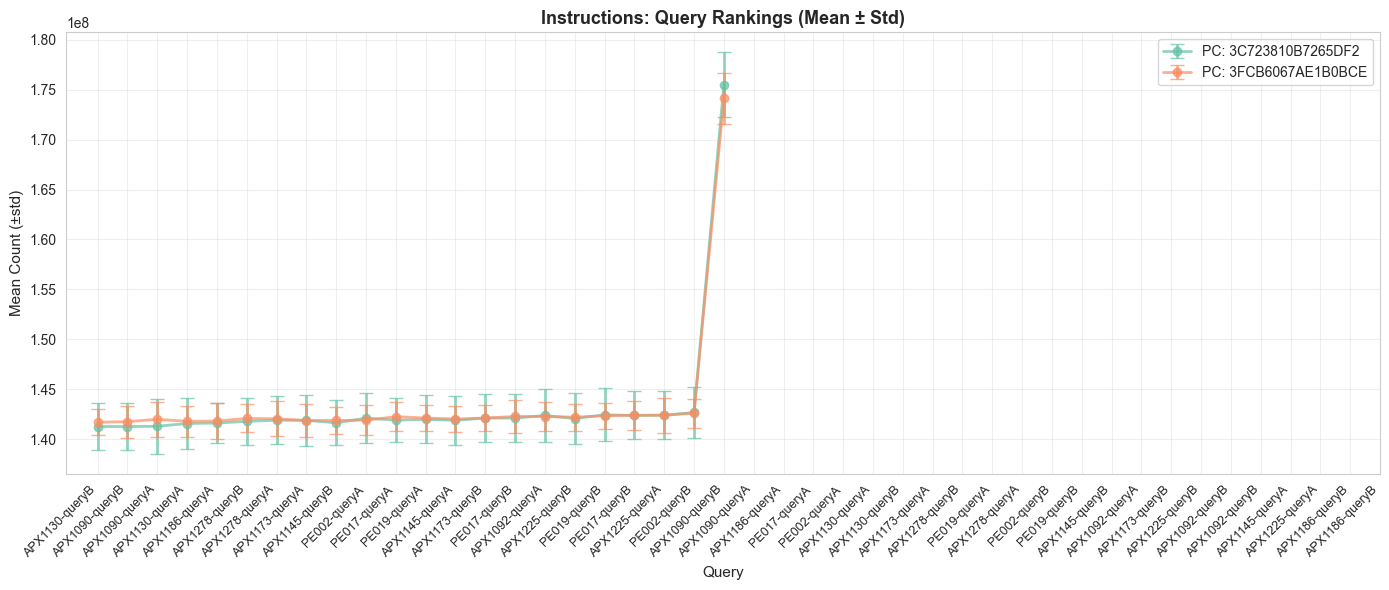

✓ Query ranking (instructions) created


In [91]:
# Query ranking: Instructions
fig, ax = plt.subplots(figsize=(14, 6))

event_stats = query_event_stats[query_event_stats["event"] == "instructions"].copy()
event_stats = event_stats.sort_values("median_value", ascending=True)

if not event_stats.empty:
    x_pos = np.arange(len(event_stats))
    
    for pc_id in event_stats["pc_id"].unique():
        pc_data = event_stats[event_stats["pc_id"] == pc_id]
        ax.errorbar(
            x_pos[:len(pc_data)],
            pc_data["mean_value"],
            yerr=pc_data["std_value"],
            fmt="o-",
            label=f"PC: {pc_id}",
            alpha=0.7,
            capsize=5,
            linewidth=2
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=9)
    ax.set_title("Instructions: Query Rankings (Mean ± Std)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Count (±std)", fontsize=11)
    ax.set_xlabel("Query", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query ranking (instructions) created")

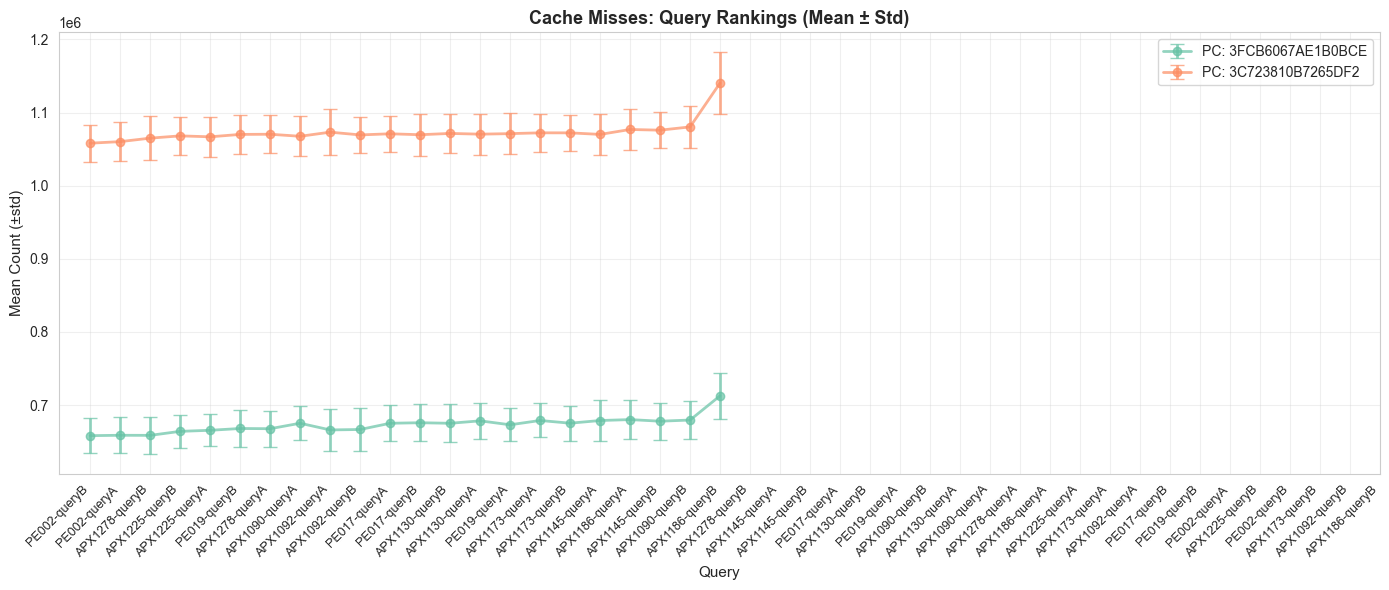

✓ Query ranking (cache-misses) created


In [92]:
# Query ranking: Cache Misses
fig, ax = plt.subplots(figsize=(14, 6))

event_stats = query_event_stats[query_event_stats["event"] == "cache-misses"].copy()
event_stats = event_stats.sort_values("median_value", ascending=True)

if not event_stats.empty:
    x_pos = np.arange(len(event_stats))
    
    for pc_id in event_stats["pc_id"].unique():
        pc_data = event_stats[event_stats["pc_id"] == pc_id]
        ax.errorbar(
            x_pos[:len(pc_data)],
            pc_data["mean_value"],
            yerr=pc_data["std_value"],
            fmt="o-",
            label=f"PC: {pc_id}",
            alpha=0.7,
            capsize=5,
            linewidth=2
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=9)
    ax.set_title("Cache Misses: Query Rankings (Mean ± Std)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Count (±std)", fontsize=11)
    ax.set_xlabel("Query", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query ranking (cache-misses) created")

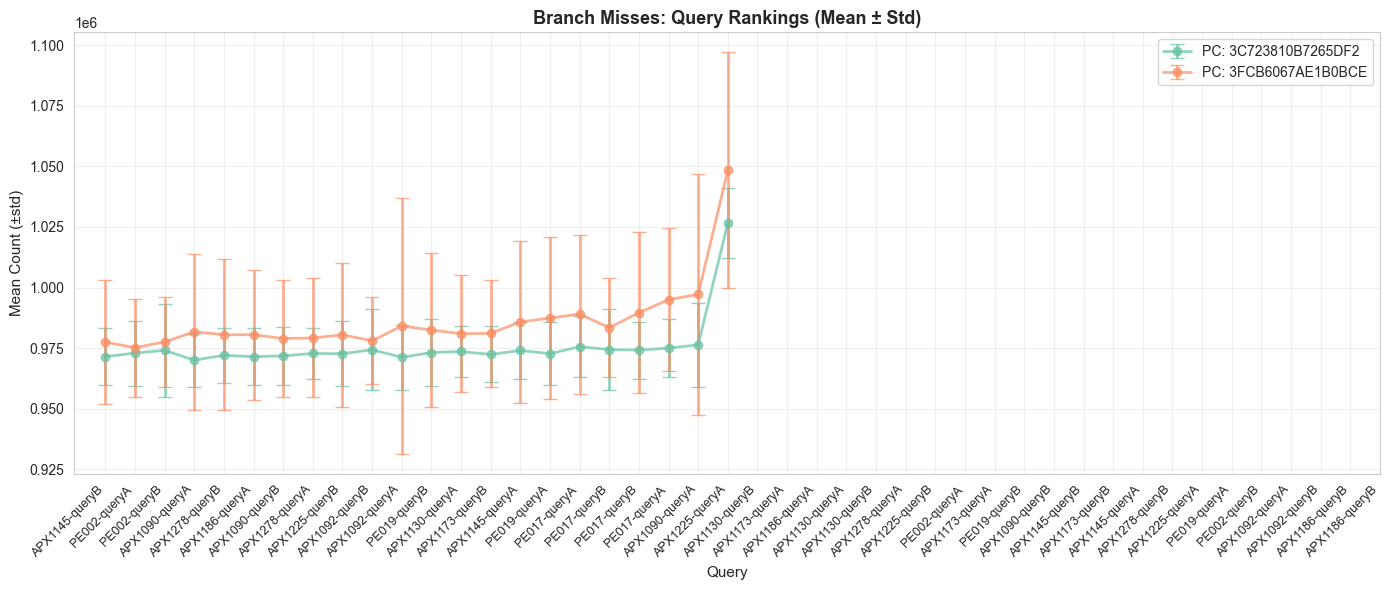

✓ Query ranking (branch-misses) created


In [93]:
# Query ranking: Branch Misses
fig, ax = plt.subplots(figsize=(14, 6))

event_stats = query_event_stats[query_event_stats["event"] == "branch-misses"].copy()
event_stats = event_stats.sort_values("median_value", ascending=True)

if not event_stats.empty:
    x_pos = np.arange(len(event_stats))
    
    for pc_id in event_stats["pc_id"].unique():
        pc_data = event_stats[event_stats["pc_id"] == pc_id]
        ax.errorbar(
            x_pos[:len(pc_data)],
            pc_data["mean_value"],
            yerr=pc_data["std_value"],
            fmt="o-",
            label=f"PC: {pc_id}",
            alpha=0.7,
            capsize=5,
            linewidth=2
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=9)
    ax.set_title("Branch Misses: Query Rankings (Mean ± Std)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Count (±std)", fontsize=11)
    ax.set_xlabel("Query", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query ranking (branch-misses) created")

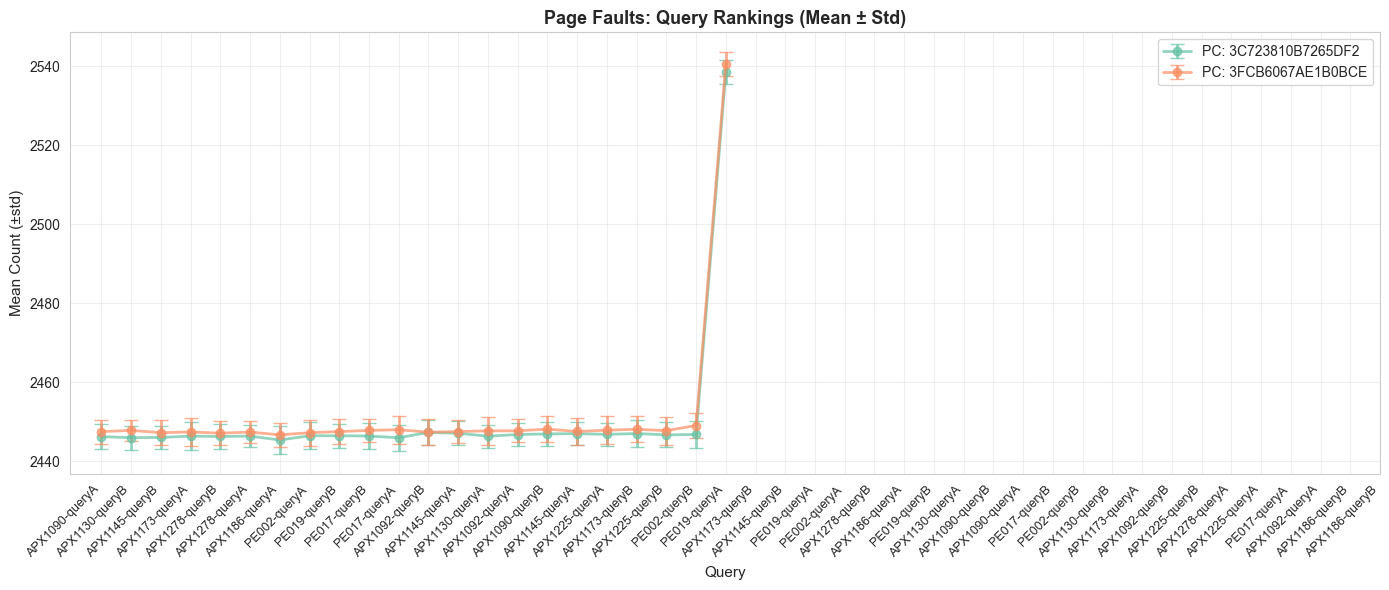

✓ Query ranking (page-faults) created


In [94]:
# Query ranking: Page Faults
fig, ax = plt.subplots(figsize=(14, 6))

event_stats = query_event_stats[query_event_stats["event"] == "page-faults"].copy()
event_stats = event_stats.sort_values("median_value", ascending=True)

if not event_stats.empty:
    x_pos = np.arange(len(event_stats))
    
    for pc_id in event_stats["pc_id"].unique():
        pc_data = event_stats[event_stats["pc_id"] == pc_id]
        ax.errorbar(
            x_pos[:len(pc_data)],
            pc_data["mean_value"],
            yerr=pc_data["std_value"],
            fmt="o-",
            label=f"PC: {pc_id}",
            alpha=0.7,
            capsize=5,
            linewidth=2
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=9)
    ax.set_title("Page Faults: Query Rankings (Mean ± Std)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Count (±std)", fontsize=11)
    ax.set_xlabel("Query", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query ranking (page-faults) created")

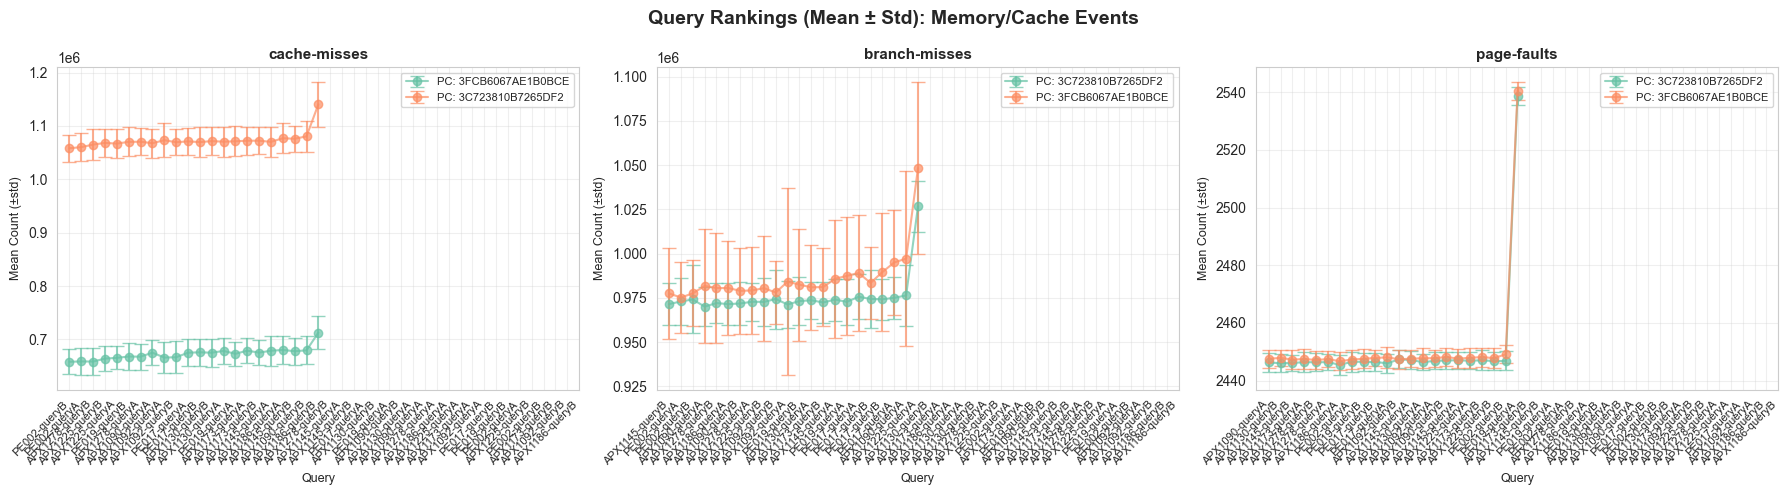

✓ Query rankings (memory/cache events) created


In [95]:
# Query ranking with error bars: Memory/Cache Events
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Query Rankings (Mean ± Std): Memory/Cache Events", fontsize=14, fontweight="bold")

memory_ranking = ["cache-misses", "branch-misses", "page-faults"]

for idx, event in enumerate(memory_ranking):
    ax = axes[idx]
    
    event_stats = query_event_stats[query_event_stats["event"] == event].copy()
    event_stats = event_stats.sort_values("median_value", ascending=True)
    
    if not event_stats.empty:
        x_pos = np.arange(len(event_stats))
        
        for pc_id in event_stats["pc_id"].unique():
            pc_data = event_stats[event_stats["pc_id"] == pc_id]
            ax.errorbar(
                x_pos[:len(pc_data)],
                pc_data["mean_value"],
                yerr=pc_data["std_value"],
                fmt="o-",
                label=f"PC: {pc_id}",
                alpha=0.7,
                capsize=5
            )
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(event_stats["query_name"], rotation=45, ha="right", fontsize=8)
        ax.set_title(event, fontsize=11, fontweight="bold")
        ax.set_ylabel("Mean Count (±std)", fontsize=9)
        ax.set_xlabel("Query", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Query rankings (memory/cache events) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1669685141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1669685141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1669685141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\1669685141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

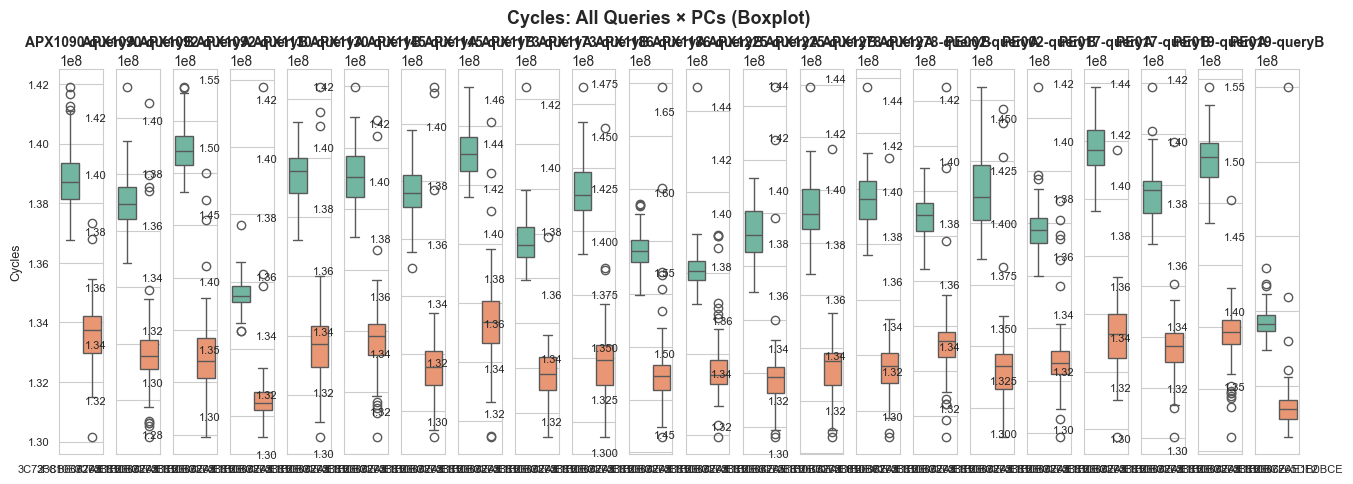

✓ Faceted grid (cycles) created


In [96]:
import matplotlib.gridspec as gridspec

# Faceted grid: Cycles across all queries and PCs
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, len(plot_df["query_name"].unique()), hspace=0.3, wspace=0.3)

queries_sorted = sorted(plot_df["query_name"].unique())

for q_idx, query in enumerate(queries_sorted):
    ax = fig.add_subplot(gs[0, q_idx])
    
    subset = plot_df[(plot_df["event"] == "cycles") & (plot_df["query_name"] == query)]
    
    if not subset.empty:
        sns.boxplot(
            data=subset,
            x="pc_id",
            y="value_raw",
            ax=ax,
            palette="Set2"
        )
        ax.set_title(f"{query}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Cycles" if q_idx == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Cycles: All Queries × PCs (Boxplot)", fontsize=13, fontweight="bold", y=1.00)
plt.show()

print("✓ Faceted grid (cycles) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3277133891.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3277133891.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3277133891.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3277133891.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

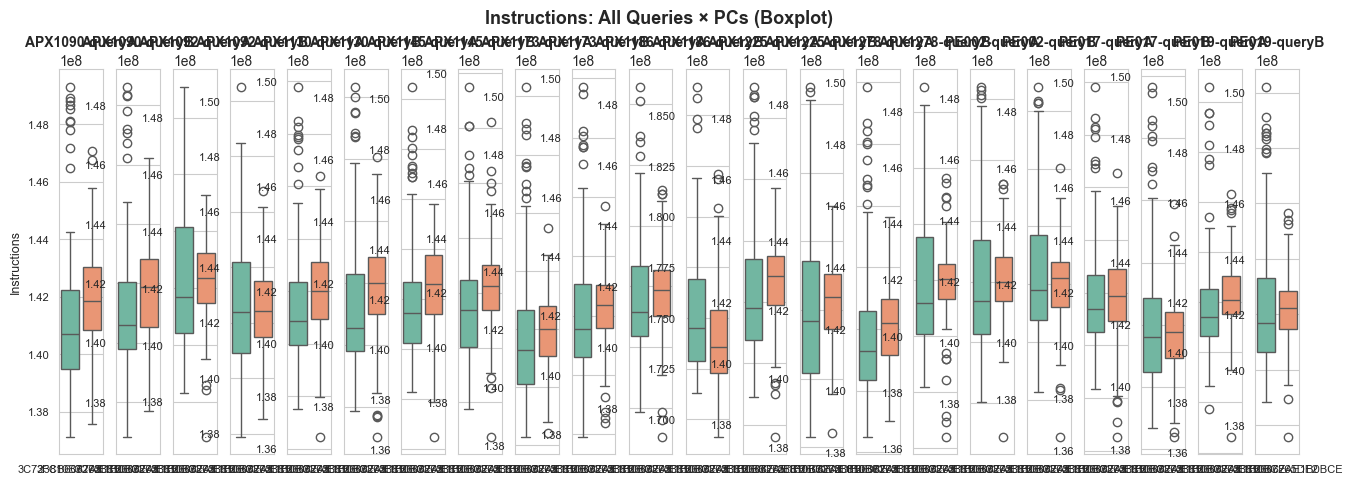

✓ Faceted grid (instructions) created


In [97]:
# Faceted grid: Instructions across all queries and PCs
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, len(queries_sorted), hspace=0.3, wspace=0.3)

for q_idx, query in enumerate(queries_sorted):
    ax = fig.add_subplot(gs[0, q_idx])
    
    subset = plot_df[(plot_df["event"] == "instructions") & (plot_df["query_name"] == query)]
    
    if not subset.empty:
        sns.boxplot(
            data=subset,
            x="pc_id",
            y="value_raw",
            ax=ax,
            palette="Set2"
        )
        ax.set_title(f"{query}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Instructions" if q_idx == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Instructions: All Queries × PCs (Boxplot)", fontsize=13, fontweight="bold", y=1.00)
plt.show()

print("✓ Faceted grid (instructions) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\76683955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\76683955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\76683955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\76683955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

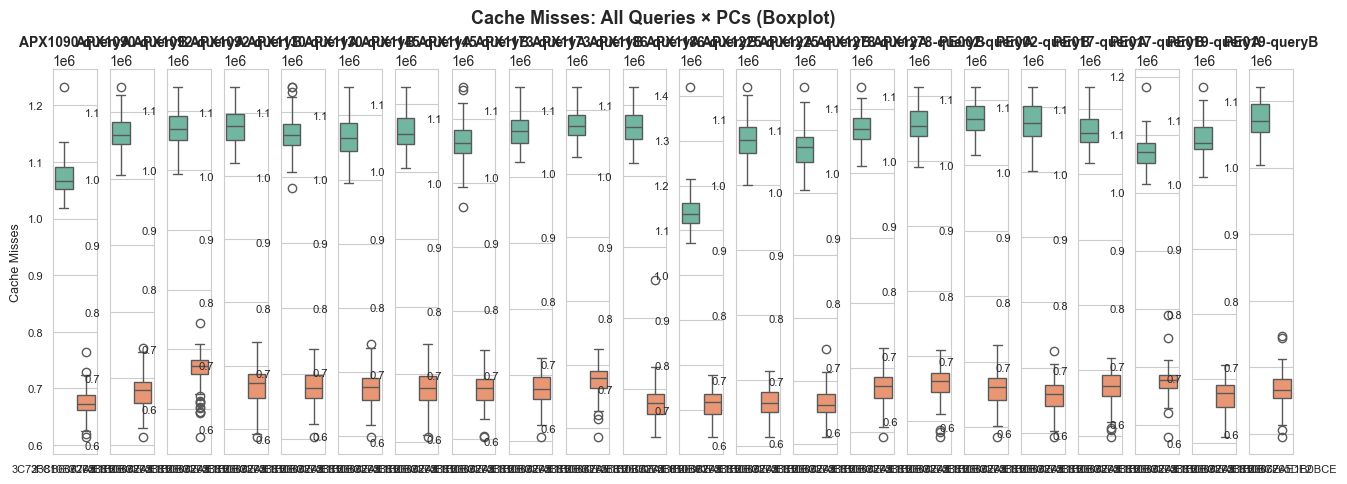

✓ Faceted grid (cache-misses) created


In [98]:
# Faceted grid: Cache Misses across all queries and PCs
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, len(queries_sorted), hspace=0.3, wspace=0.3)

for q_idx, query in enumerate(queries_sorted):
    ax = fig.add_subplot(gs[0, q_idx])
    
    subset = plot_df[(plot_df["event"] == "cache-misses") & (plot_df["query_name"] == query)]
    
    if not subset.empty:
        sns.boxplot(
            data=subset,
            x="pc_id",
            y="value_raw",
            ax=ax,
            palette="Set2"
        )
        ax.set_title(f"{query}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Cache Misses" if q_idx == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Cache Misses: All Queries × PCs (Boxplot)", fontsize=13, fontweight="bold", y=1.00)
plt.show()

print("✓ Faceted grid (cache-misses) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2590984129.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2590984129.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2590984129.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\2590984129.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

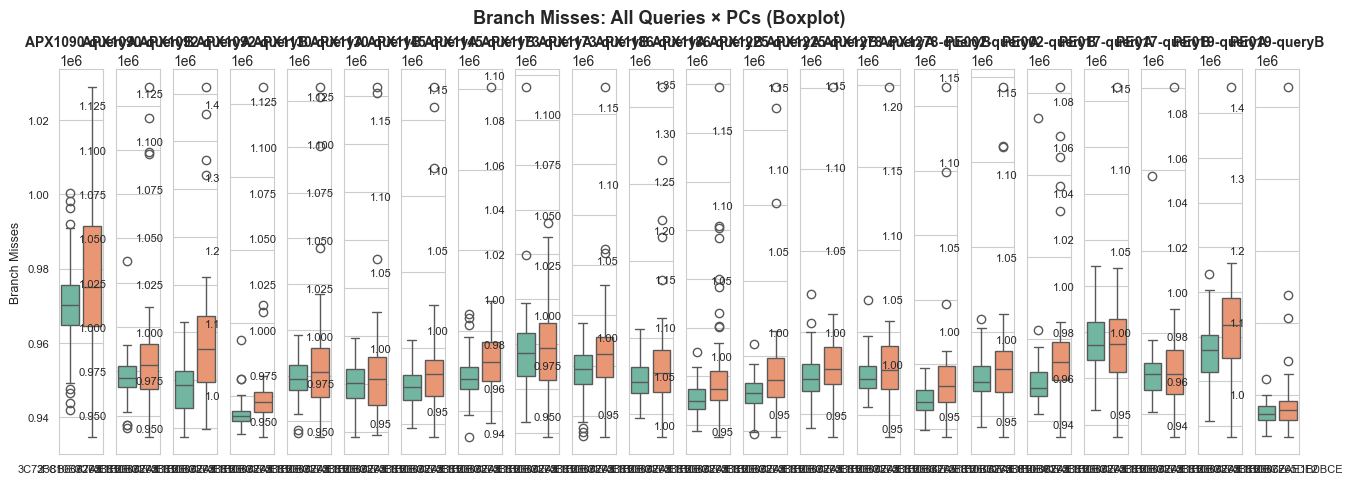

✓ Faceted grid (branch-misses) created


In [99]:
# Faceted grid: Branch Misses across all queries and PCs
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, len(queries_sorted), hspace=0.3, wspace=0.3)

for q_idx, query in enumerate(queries_sorted):
    ax = fig.add_subplot(gs[0, q_idx])
    
    subset = plot_df[(plot_df["event"] == "branch-misses") & (plot_df["query_name"] == query)]
    
    if not subset.empty:
        sns.boxplot(
            data=subset,
            x="pc_id",
            y="value_raw",
            ax=ax,
            palette="Set2"
        )
        ax.set_title(f"{query}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Branch Misses" if q_idx == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Branch Misses: All Queries × PCs (Boxplot)", fontsize=13, fontweight="bold", y=1.00)
plt.show()

print("✓ Faceted grid (branch-misses) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3268073050.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3268073050.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3268073050.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\3268073050.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

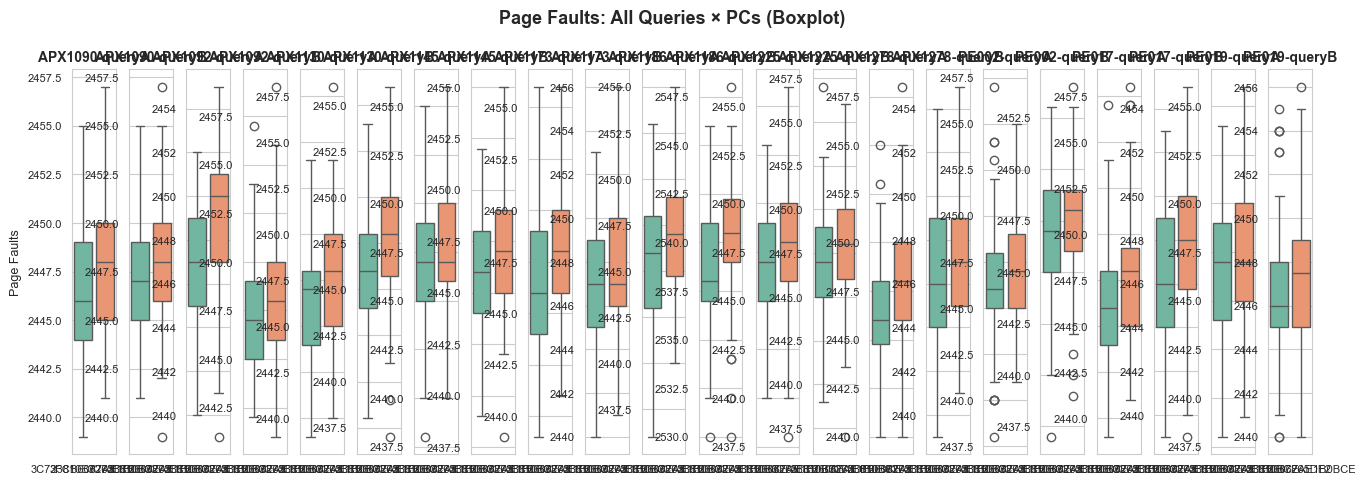

✓ Faceted grid (page-faults) created


In [100]:
# Faceted grid: Page Faults across all queries and PCs
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, len(queries_sorted), hspace=0.3, wspace=0.3)

for q_idx, query in enumerate(queries_sorted):
    ax = fig.add_subplot(gs[0, q_idx])
    
    subset = plot_df[(plot_df["event"] == "page-faults") & (plot_df["query_name"] == query)]
    
    if not subset.empty:
        sns.boxplot(
            data=subset,
            x="pc_id",
            y="value_raw",
            ax=ax,
            palette="Set2"
        )
        ax.set_title(f"{query}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Page Faults" if q_idx == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Page Faults: All Queries × PCs (Boxplot)", fontsize=13, fontweight="bold", y=1.00)
plt.show()

print("✓ Faceted grid (page-faults) created")

C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4183668175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4183668175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4183668175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matthias\AppData\Local\Temp\ipykernel_19472\4183668175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

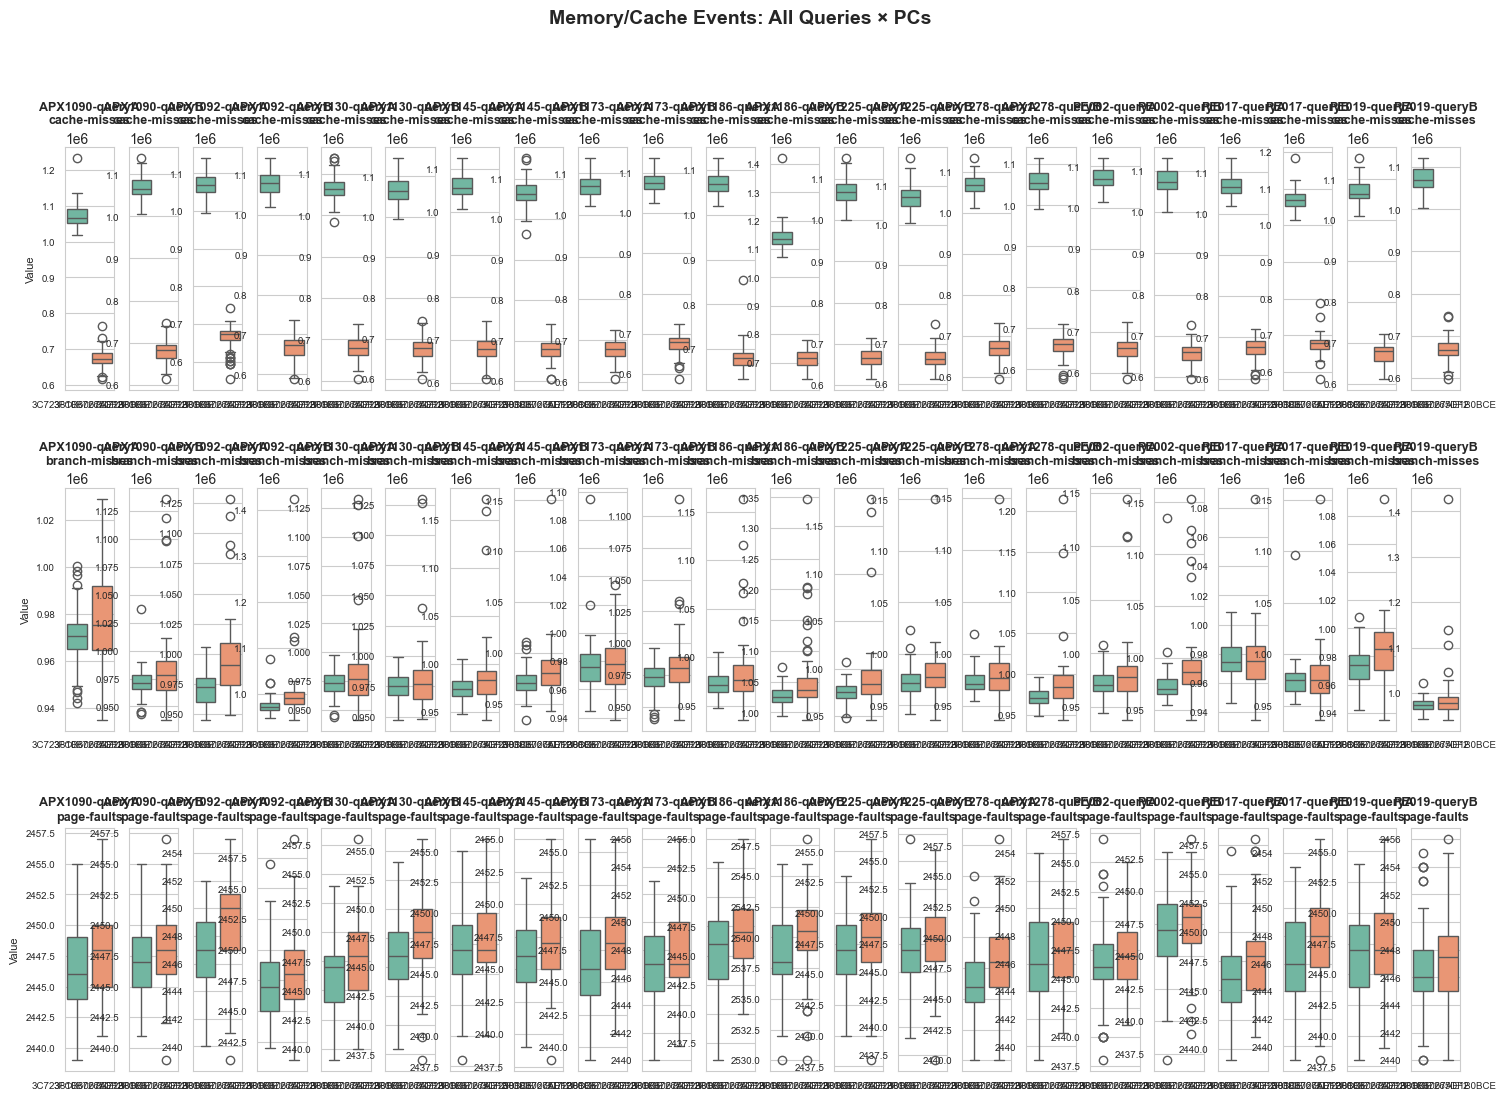

✓ Faceted view (memory/cache events) created


In [101]:
# Faceted view: Memory/Cache Events across all queries
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, len(plot_df["query_name"].unique()), hspace=0.4, wspace=0.3)

memory_events_facet = ["cache-misses", "branch-misses", "page-faults"]

for e_idx, event in enumerate(memory_events_facet):
    for q_idx, query in enumerate(queries_sorted):
        ax = fig.add_subplot(gs[e_idx, q_idx])
        
        subset = plot_df[(plot_df["event"] == event) & (plot_df["query_name"] == query)]
        
        if not subset.empty:
            sns.boxplot(
                data=subset,
                x="pc_id",
                y="value_raw",
                ax=ax,
                palette="Set2"
            )
            title = f"{query}\n{event}"
            ax.set_title(title, fontsize=9, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Value" if q_idx == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])

fig.suptitle("Memory/Cache Events: All Queries × PCs", fontsize=14, fontweight="bold", y=0.995)
plt.show()

print("✓ Faceted view (memory/cache events) created")